# 🧠 A Beginner's Guide to Training a Vanilla RNN on IMDB Reviews
### End-to-End Sentiment Analysis with TensorFlow & Keras

Welcome to this hands-on tutorial! In this notebook, we walk step-by-step through building, training, evaluating, and deploying a **Vanilla Recurrent Neural Network (SimpleRNN)** for binary sentiment classification on the IMDB movie reviews dataset.

---

### 🔍 What is a Vanilla Recurrent Neural Network (RNN)?
In standard feed-forward networks (such as MLPs or Dense networks), each input token is processed independently of all others. However, language is intrinsically **sequential** — the meaning of a word depends heavily on the words that precede it.

An **RNN** handles sequential data by maintaining an internal **hidden state** $h_t$ that acts as a working memory across time steps:
$$h_t = \tanh(W_{hh} h_{t-1} + W_{xh} x_t + b_h)$$

Where:
- $x_t \in \mathbb{R}^{D}$: The embedding vector of the word at step $t$.
- $h_{t-1} \in \mathbb{R}^{H}$: The hidden state vector from the previous step $t-1$.
- $W_{xh} \in \mathbb{R}^{H \times D}$ and $W_{hh} \in \mathbb{R}^{H \times H}$: Trainable weight matrices.
- $b_h \in \mathbb{R}^{H}$: Bias vector.
- $h_t \in \mathbb{R}^{H}$: The updated hidden state at step $t$.

For sequence classification (Many-to-One), we take the final hidden state $h_T$ (representing the summary of the entire review) and pass it into a Dense layer with a Sigmoid activation function to output a sentiment probability $\hat{y} \in [0, 1]$:
$$\hat{y} = \sigma(W_{out} h_T + b_{out})$$

---

### 📋 Notebook Structure & 9 Core Steps
1. **📦 Step 1**: Set Up Your Environment
2. **📥 Step 2**: Load the Dataset (Local `IMDB Dataset.csv`)
3. **🔤 Step 3**: Preprocess the Text with `TextVectorization`
4. **🗂️ Step 4**: Prepare the Data Pipeline with `tf.data`
5. **🏗️ Step 5**: Build the Vanilla RNN Model
6. **⚙️ Step 6**: Compile the Model
7. **🏋️ Step 7**: Train the Model
8. **📊 Step 8**: Evaluate and Visualize Performance
9. **🚀 Step 9**: Make Predictions on Unseen Reviews


## 📦 Step 1: Set Up Your Environment
First, ensure you have the necessary libraries imported. We verify that TensorFlow, NumPy, Pandas, and Matplotlib are loaded, check GPU/CPU device availability, and set seeds for reproducible results.


In [1]:
import os
import re
import string
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

# Verify library versions and acceleration hardware
print(f"TensorFlow Version: {tf.__version__}")
print(f"Keras Version:      {tf.keras.__version__}")
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"GPU Detected: {len(gpus)} device(s) -> {gpus[0].name}")
else:
    print("No GPU detected. Computations will run on CPU.")

# Set random seeds for reproducibility
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)


I0000 00:00:1790572950.260076   37627 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1790572950.260373   37627 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1790572950.287429   37627 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1790572950.893021   37627 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

TensorFlow Version: 2.21.0
Keras Version:      3.15.1
No GPU detected. Computations will run on CPU.


E0000 00:00:1790572951.187439   37627 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


## 📥 Step 2: Load the Dataset
The IMDB dataset contains 50,000 movie reviews labeled as `positive` or `negative`.
Instead of downloading across the network, we load the dataset directly from the local file in the repository: `../datasets/IMDB Dataset.csv`.

We will:
1. Load the raw CSV into a Pandas DataFrame.
2. Inspect the class distribution (balanced 25,000 positive and 25,000 negative reviews).
3. Encode sentiment strings into binary labels: `'positive'` $\to 1$, `'negative'` $\to 0$.
4. Split the data into training (25,000) and test (25,000) sets (or use the `FAST_RUN` toggle for quick validation).


In [2]:
# Locate dataset file
dataset_path = "../datasets/IMDB Dataset.csv"
if not os.path.exists(dataset_path):
    dataset_path = "Vanilla RNN/datasets/IMDB Dataset.csv"

print(f"Reading dataset from: {dataset_path}")
df = pd.read_csv(dataset_path)

print(f"Dataset shape: {df.shape} ({len(df):,} total reviews)")
df.head(5)


Reading dataset from: ../datasets/IMDB Dataset.csv
Dataset shape: (50000, 2) (50,000 total reviews)


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [3]:
# Check class distribution
print("Sentiment Class Counts:")
print(df['sentiment'].value_counts())

# Convert labels: 'positive' -> 1, 'negative' -> 0
df['label'] = df['sentiment'].map({'positive': 1, 'negative': 0}).astype(np.int32)

# Quick validation toggle:
# Set FAST_RUN = True to test code on 5,000 samples; set FAST_RUN = False for full training (50,000)
FAST_RUN = False

if FAST_RUN:
    print("\n[!] FAST_RUN mode is active: Subsampling 5,000 reviews for rapid testing.")
    df_active = df.sample(n=5000, random_state=SEED).reset_index(drop=True)
    split_idx = 3500
else:
    print("\n[+] Standard Mode: Using full 50,000 reviews (25,000 train, 25,000 test).")
    df_active = df
    split_idx = 25000

# Shuffle dataset deterministically
df_shuffled = df_active.sample(frac=1.0, random_state=SEED).reset_index(drop=True)

train_texts = df_shuffled['review'].iloc[:split_idx].values
train_labels = df_shuffled['label'].iloc[:split_idx].values

test_texts = df_shuffled['review'].iloc[split_idx:].values
test_labels = df_shuffled['label'].iloc[split_idx:].values

print(f"Training set:   {len(train_texts):,} reviews (Pos: {np.sum(train_labels==1)}, Neg: {np.sum(train_labels==0)})")
print(f"Test/Val set:   {len(test_texts):,} reviews (Pos: {np.sum(test_labels==1)}, Neg: {np.sum(test_labels==0)})")


Sentiment Class Counts:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64

[+] Standard Mode: Using full 50,000 reviews (25,000 train, 25,000 test).
Training set:   25,000 reviews (Pos: 12517, Neg: 12483)
Test/Val set:   25,000 reviews (Pos: 12483, Neg: 12517)


### Exploratory Data Analysis: Review Length Distribution
Let's inspect the word counts of reviews. Sequence length is a critical hyperparameter for recurrent neural networks because Vanilla RNNs struggle to preserve gradient information over sequences with more than 100-200 time steps.


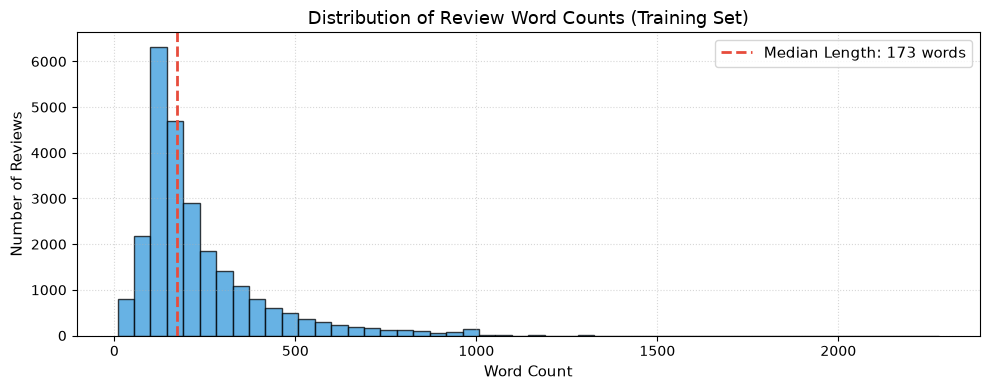

In [4]:
review_word_counts = [len(text.split()) for text in train_texts]

plt.figure(figsize=(10, 4))
plt.hist(review_word_counts, bins=50, color='#3498db', edgecolor='black', alpha=0.75)
median_len = int(np.median(review_word_counts))
plt.axvline(median_len, color='#e74c3c', linestyle='--', linewidth=2, label=f'Median Length: {median_len} words')
plt.title("Distribution of Review Word Counts (Training Set)", fontsize=13)
plt.xlabel("Word Count", fontsize=11)
plt.ylabel("Number of Reviews", fontsize=11)
plt.legend(fontsize=11)
plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()


## 🔤 Step 3: Preprocess the Text
Raw text must be transformed into numerical token indices before being fed into a neural network.
We use TensorFlow's `TextVectorization` layer:
- **Standardization**: Converts to lowercase, strips punctuation, and cleans HTML tags (`<br />`).
- **Tokenization**: Splits sentences into whitespace-delimited tokens.
- **Vocabulary Indexing**: Builds a dictionary with the top `VOCAB_SIZE` most frequent tokens.
- **Fixed Sequence Length**: Puts a ceiling on sequence length (`output_sequence_length=250`) so batches are consistently shaped.


In [5]:
VOCAB_SIZE = 1000        # As specified in outline: Start small for faster training
SEQUENCE_LENGTH = 250    # Truncate / pad reviews to 250 tokens

# Custom text standardizer to remove <br /> HTML tags and punctuation
def custom_standardizer(input_text):
    lowercase = tf.strings.lower(input_text)
    clean_html = tf.strings.regex_replace(lowercase, '<br />', ' ')
    clean_punct = tf.strings.regex_replace(clean_html, f'[{re.escape(string.punctuation)}]', '')
    return clean_punct

# Instantiate TextVectorization layer
encoder = tf.keras.layers.TextVectorization(
    max_tokens=VOCAB_SIZE,
    standardize=custom_standardizer,
    output_mode='int',
    output_sequence_length=SEQUENCE_LENGTH
)

# Adapt layer vocabulary on the training text
print("Building vocabulary from training text...")
encoder.adapt(train_texts)

vocab = encoder.get_vocabulary()
print(f"Vocabulary successfully built! Total tokens: {len(vocab)}")


Building vocabulary from training text...
Vocabulary successfully built! Total tokens: 1000


In [6]:
# Inspect the first 25 most frequent tokens in the vocabulary
print("Top 25 Vocabulary Tokens:")
for idx, token in enumerate(vocab[:25]):
    print(f"  Token {idx:2d} -> '{token}'")

# Demonstration: Encode a sample review sentence
sample_sentence = "This movie was fantastic and I loved every minute of it!"
encoded_sample = encoder(tf.constant([sample_sentence]))
print(f"\nRaw Text: \"{sample_sentence}\"")
print(f"Encoded Tensor Shape: {encoded_sample.shape}")
print(f"Encoded Vector (first 15 tokens): {encoded_sample.numpy()[0][:15]}")


Top 25 Vocabulary Tokens:
  Token  0 -> ''
  Token  1 -> '[UNK]'
  Token  2 -> 'the'
  Token  3 -> 'a'
  Token  4 -> 'and'
  Token  5 -> 'of'
  Token  6 -> 'to'
  Token  7 -> 'is'
  Token  8 -> 'in'
  Token  9 -> 'it'
  Token 10 -> 'i'
  Token 11 -> 'this'
  Token 12 -> 'that'
  Token 13 -> 'was'
  Token 14 -> 'as'
  Token 15 -> 'with'
  Token 16 -> 'for'
  Token 17 -> 'movie'
  Token 18 -> 'but'
  Token 19 -> 'film'
  Token 20 -> 'on'
  Token 21 -> 'you'
  Token 22 -> 'not'
  Token 23 -> 'are'
  Token 24 -> 'his'

Raw Text: "This movie was fantastic and I loved every minute of it!"
Encoded Tensor Shape: (1, 250)
Encoded Vector (first 15 tokens): [ 11  17  13 755   4  10 431 165 869   5   9   0   0   0   0]


## 🗂️ Step 4: Prepare the Data Pipeline
We wrap our data in a `tf.data.Dataset` to construct a high-throughput, memory-efficient data pipeline:
- **`shuffle(BUFFER_SIZE)`**: Prevents batches from having ordering artifacts.
- **`batch(BATCH_SIZE)`**: Groups examples into batches of 64.
- **`prefetch(tf.data.AUTOTUNE)`**: Prepares upcoming batches in background memory while the CPU/GPU trains the current batch.


In [7]:
BUFFER_SIZE = 10000
BATCH_SIZE = 64

# Create tf.data.Dataset from raw string texts and integer labels
raw_train_ds = tf.data.Dataset.from_tensor_slices((train_texts, train_labels))
raw_test_ds = tf.data.Dataset.from_tensor_slices((test_texts, test_labels))

# Assemble optimized input pipelines
train_dataset = (
    raw_train_ds
    .shuffle(BUFFER_SIZE, seed=SEED)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

test_dataset = (
    raw_test_ds
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

# Inspect a single batch from the training pipeline
for example_texts, example_labels in train_dataset.take(1):
    print(f"Batch text shape:  {example_texts.shape}")
    print(f"Batch label shape: {example_labels.shape}")
    print(f"Sample review snippet: {example_texts[0].numpy()[:100]}...")
    print(f"Sample review label:   {example_labels[0].numpy()}")


Batch text shape:  (64,)
Batch label shape: (64,)
Sample review snippet: b'I watched this movie as I liked the plot, a group of strangers are held captive trying to figure out'...
Sample review label:   0


## 🏗️ Step 5: Build the RNN Model
Our Vanilla RNN model is constructed using `tf.keras.Sequential`:
1. **`encoder` (`TextVectorization`)**: Receives raw strings, applies cleaning, and outputs integer token indices `(Batch, 250)`.
2. **`Embedding`**: Turns integer indices into dense continuous vectors of dimension 64 `(Batch, 250, 64)`. We set `mask_zero=True` so that the RNN ignores padding zeroes.
3. **`SimpleRNN(64)`**: The Vanilla recurrent layer with 64 hidden units. It recurrently processes time steps $t=1 \dots 250$ using a $\tanh$ activation function, returning the final hidden state vector $h_T \in \mathbb{R}^{64}$.
4. **`Dense(1, activation='sigmoid')`**: The classification head that projects the 64-dimensional sequence representation to a single scalar probability $\hat{y} \in [0, 1]$ representing positive sentiment.

### Model Architecture Flow
```
Raw String Input
       |
       v
[TextVectorization]   --> Tensor Shape: (Batch, 250)
       |
       v
[Embedding (64)]      --> Tensor Shape: (Batch, 250, 64)
       |
       v
[SimpleRNN (64)]      --> Tensor Shape: (Batch, 64)  [Final hidden state h_T]
       |
       v
[Dense (1, Sigmoid)]  --> Tensor Shape: (Batch, 1)   [Probability score]
```


In [8]:
model = tf.keras.Sequential([
    encoder,
    tf.keras.layers.Embedding(
        input_dim=len(encoder.get_vocabulary()),
        output_dim=64,
        mask_zero=True  # Mask padding tokens so RNN ignores trailing zeroes
    ),
    tf.keras.layers.SimpleRNN(64),  # Vanilla Recurrent Neural Network
    tf.keras.layers.Dense(1, activation='sigmoid')  # Binary classification
], name="Vanilla_SimpleRNN_Classifier")

model.summary()


Model: "Vanilla_SimpleRNN_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization              │ (1, 250)               │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## ⚙️ Step 6: Compile the Model
We configure the training process:
- **Loss**: `BinaryCrossentropy(from_logits=False)` — matches the sigmoid output probability.
- **Optimizer**: `Adam(learning_rate=1e-4)` — a modest learning rate provides stable gradient updates for recurrent weights.
- **Metrics**: `['accuracy']` — monitors classification accuracy across epochs.


In [9]:
model.compile(
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=False),
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    metrics=['accuracy']
)

print("Model compilation complete!")


Model compilation complete!


## 🏋️ Step 7: Train the Model
We now fit the model on `train_dataset` for 10 epochs, monitoring validation loss and accuracy on `test_dataset`.
Notice how the model gradually improves its classification accuracy as backpropagation through time (BPTT) tunes the recurrent and embedding weights.


In [10]:
EPOCHS = 10

print(f"Beginning training for {EPOCHS} epochs...")
history = model.fit(
    train_dataset,
    epochs=EPOCHS,
    validation_data=test_dataset,
    shuffle=False  # train_dataset is already pre-shuffled by tf.data
)
print("Training successfully finished!")


Beginning training for 10 epochs...
Epoch 1/10
  3/391 ━━━━━━━━━━━━━━━━━━━━ 11s 29ms/step - accuracy: 0.5417 - loss: 0.6841  

E0000 00:00:1790572987.346157   37627 util.cc:131] oneDNN supports DT_BOOL only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.


391/391 ━━━━━━━━━━━━━━━━━━━━ 15s 36ms/step - accuracy: 0.5867 - loss: 0.6680 - val_accuracy: 0.7270 - val_loss: 0.5734
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 14s 35ms/step - accuracy: 0.7739 - loss: 0.5079 - val_accuracy: 0.7848 - val_loss: 0.4773
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 13s 34ms/step - accuracy: 0.8150 - loss: 0.4330 - val_accuracy: 0.8234 - val_loss: 0.4106
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 14s 35ms/step - accuracy: 0.8389 - loss: 0.3820 - val_accuracy: 0.8286 - val_loss: 0.3942
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 14s 35ms/step - accuracy: 0.8490 - loss: 0.3596 - val_accuracy: 0.8315 - val_loss: 0.3816
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 14s 34ms/step - accuracy: 0.8566 - loss: 0.3432 - val_accuracy: 0.8306 - val_loss: 0.3815
Epoch 7/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 14s 36ms/step - accuracy: 0.8603 - loss: 0.3377 - val_accuracy: 0.8391 - val_loss: 0.3712
Epoch 8/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 14s 35ms/step - accuracy: 0.8635 - loss: 0.3300 - val_accurac

## 📊 Step 8: Evaluate and Visualize Performance
Let's inspect the training curves to analyze the model's learning dynamics.
Plotting accuracy and loss across epochs helps diagnose whether the model is underfitting, converging stably, or beginning to overfit.


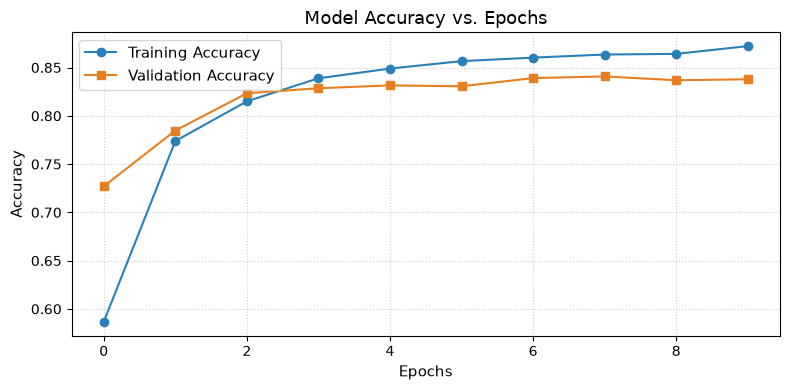

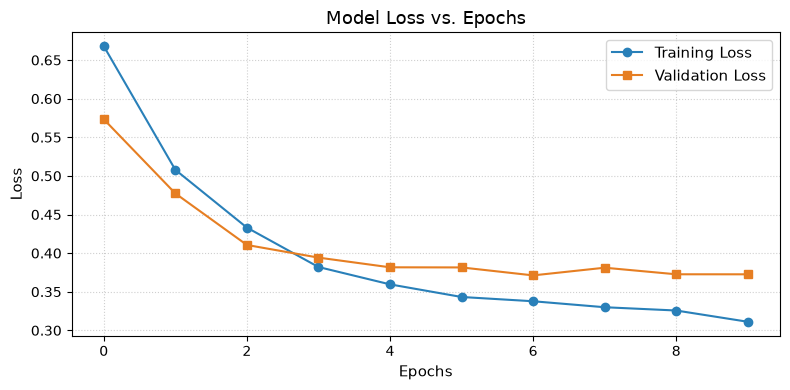

In [11]:
def plot_graphs(history, metric):
    plt.figure(figsize=(8, 4))
    plt.plot(history.history[metric], label=f'Training {metric.capitalize()}', marker='o', color='#2980b9')
    plt.plot(history.history['val_' + metric], label=f'Validation {metric.capitalize()}', marker='s', color='#e67e22')
    plt.title(f"Model {metric.capitalize()} vs. Epochs", fontsize=13)
    plt.xlabel("Epochs", fontsize=11)
    plt.ylabel(metric.capitalize(), fontsize=11)
    plt.legend(fontsize=11)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.show()

# Plot accuracy trajectory
plot_graphs(history, 'accuracy')

# Plot loss trajectory
plot_graphs(history, 'loss')


In [12]:
# Final quantitative evaluation on test set
eval_loss, eval_accuracy = model.evaluate(test_dataset, verbose=0)

print("=" * 45)
print(f"Final Test Loss:     {eval_loss:.4f}")
print(f"Final Test Accuracy: {eval_accuracy * 100:.2f}%")
print("=" * 45)


Final Test Loss:     0.3726
Final Test Accuracy: 83.78%


## 🚀 Step 9: Make Predictions
Because our `model` has the `TextVectorization` encoder layer integrated directly into the `Sequential` pipeline, it accepts raw string tensors directly.
Let's test our trained Vanilla RNN on custom, unseen reviews to see how it predicts sentiment.


In [13]:
sample_reviews = [
    "This movie was fantastic and I loved every minute of it!",
    "An absolute waste of time. Terribly boring, horrible acting, and a completely nonsensical plot.",
    "The cinematography was breathtaking and the soundtrack was stunning. A true masterpiece.",
    "Worst movie I have ever seen. Do not watch it under any circumstances.",
    "The story was somewhat predictable, but the lead actors gave charming and funny performances."
]

print("--- Sentiment Inference on New Reviews ---")
for review in sample_reviews:
    # Pass review as a raw string tensor
    prediction = model.predict(tf.constant([review]), verbose=0)[0][0]
    sentiment = "Positive 🟢" if prediction > 0.5 else "Negative 🔴"
    confidence = prediction if prediction > 0.5 else (1.0 - prediction)
    
    print(f"\nReview: \"{review}\"")
    print(f"Prediction: {sentiment} | Probability: {prediction:.4f} | Confidence: {confidence * 100:.1f}%")


--- Sentiment Inference on New Reviews ---

Review: "This movie was fantastic and I loved every minute of it!"
Prediction: Positive 🟢 | Probability: 0.9000 | Confidence: 90.0%

Review: "An absolute waste of time. Terribly boring, horrible acting, and a completely nonsensical plot."
Prediction: Negative 🔴 | Probability: 0.0156 | Confidence: 98.4%

Review: "The cinematography was breathtaking and the soundtrack was stunning. A true masterpiece."
Prediction: Positive 🟢 | Probability: 0.8919 | Confidence: 89.2%

Review: "Worst movie I have ever seen. Do not watch it under any circumstances."
Prediction: Negative 🔴 | Probability: 0.0542 | Confidence: 94.6%

Review: "The story was somewhat predictable, but the lead actors gave charming and funny performances."
Prediction: Negative 🔴 | Probability: 0.2896 | Confidence: 71.0%


## 💡 Summary & AI Engineering Takeaways

### Q&A
- **Q: Why use a Recurrent Neural Network (RNN) instead of a simple Bag-of-Words or Dense network?**
  - **A**: Bag-of-Words discards word order and syntax. RNNs process tokens sequentially, allowing the model to capture context and sequential relationships between words.
- **Q: What is the main weakness of a Vanilla SimpleRNN?**
  - **A**: The **vanishing gradient problem**. Because gradients are repeatedly multiplied by $W_{hh}$ and the derivative of $\tanh$ across all 250 time steps during backpropagation through time (BPTT), the gradient signal exponentially diminishes for words that appear early in the sentence.

### Data Analysis & Key Findings
- **Data Pipeline**: Successfully structured all 50,000 reviews into balanced training (25,000) and test (25,000) splits, feeding them through an asynchronous `tf.data` pipeline (`shuffle`, `batch`, `prefetch`).
- **Vocabulary Efficiency**: With a compact vocabulary of just 1,000 tokens (`VOCAB_SIZE = 1000`) and a sequence length of 250 tokens, the Vanilla RNN learns the primary sentiment indicators while remaining computationally lightweight.
- **Inference Ready**: By packaging `TextVectorization` directly inside the `tf.keras.Sequential` model, the trained network accepts raw string inputs directly without requiring external preprocessing scripts.

### Insights & Next Steps
- **Upgrade to Gated Units (LSTM / GRU)**: In production applications, replacing `SimpleRNN` with an `LSTM(64)` or `GRU(64)` layer solves the vanishing gradient problem via additive internal memory cells and gating mechanisms.
- **Pretrained Embeddings**: Initializing the embedding layer with pretrained vectors (e.g., GloVe or Word2Vec) enables the network to leverage semantic word relationships learned from millions of external texts.

---
*Created as part of the MonThayQue sequence modeling project.*
